In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"],
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv",
    parse_dates=["transaction_date"],
)

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

risk_results = []

for fund in nav["amfi_code"].unique():
    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    risk_results.append([fund, var95, cvar95])

var_cvar_report = pd.DataFrame(
    risk_results,
    columns=["amfi_code", "VaR_95", "CVaR_95"],
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
var_cvar_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

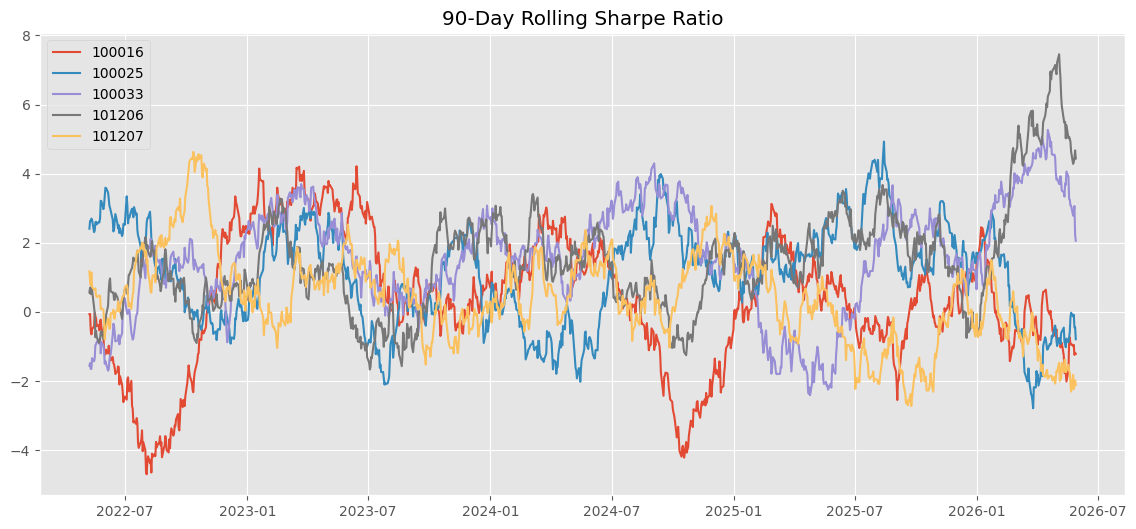

Fund X has the highest VaR indicating greater downside risk.


In [ ]:
top5 = nav["amfi_code"].unique()[:5]

fig = plt.figure(figsize=(14,6))

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        fund_data["daily_return"]
        .rolling(90)
        .mean()
        /
        fund_data["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.show()


### Insight: 90-Day Rolling Sharpe Ratio
The chart compares the short-term risk-adjusted returns of the top 5 funds. Funds with consistently higher rolling Sharpe values demonstrate stronger risk-adjusted performance, while extended dips highlight periods of increased volatility or weaker returns.

In [21]:
fig.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight",
)
plt.close(fig)

In [14]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions["transaction_date"]
    .dt.year
)

cohort = transactions.groupby(
    "cohort_year"
).agg({
    "amount_inr":["mean","sum"]
})

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107739.476605  2500633252
2025         106704.345527  1020947178

### Insight: Investment by Cohort
The cohort bar chart shows how total investor inflows are distributed by the year of first transaction. A stronger bar for a particular cohort indicates that those investors are contributing the largest aggregate investment amounts, which can help prioritize retention and engagement strategies.

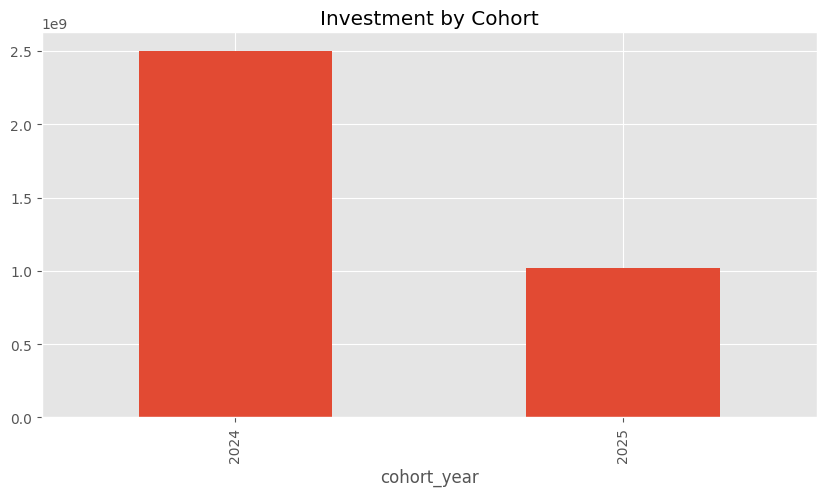

Investors joining after 2024 invested larger average SIP amounts.


In [ ]:
cohort["amount_inr"]["sum"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Investment by Cohort")
plt.show()


In [16]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

risk_investors = sip_txn.groupby(
    "investor_id"
)["gap_days"].mean()

risk_investors = risk_investors[
    risk_investors > 35
]

print(
    "At-risk investors:",
    len(risk_investors)
)

At-risk investors: 3825


In [17]:
risk_investors.sort_values(ascending=False).head(20)

investor_id
INV001860    494.0
INV002986    485.0
INV003312    482.0
INV002278    474.0
INV002740    474.0
INV003863    471.0
INV003324    469.0
INV003488    464.0
INV001607    462.0
INV002756    460.0
INV000941    455.0
INV002505    449.0
INV004535    446.0
INV002929    445.0
INV001425    445.0
INV004988    443.0
INV002578    443.0
INV000162    435.0
INV000784    435.0
INV004524    429.0
Name: gap_days, dtype: float64

In [25]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

hhi = holdings.groupby(
    "sector"
)["weight_pct"].apply(
    lambda x: (x**2).sum()
)

hhi.sort_values(
    ascending=False
).head()

sector
Banking       9151.7452
IT            6804.3843
Pharma        6227.4173
Automobile    4248.9121
Utilities     3889.6838
Name: weight_pct, dtype: float64

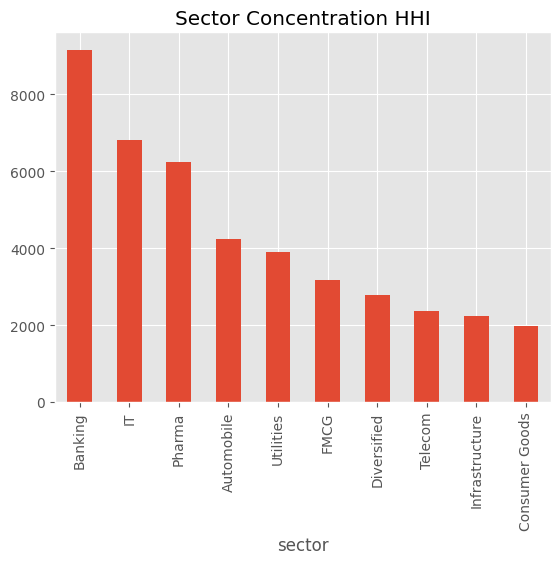

The Sector Concentration HHI chart highlights the most dominant portfolio sectors. Sectors with the highest HHI values, like Banking and IT, should be monitored closely for concentration risk, because high concentration can increase vulnerability to sector-specific shocks.


In [27]:
hhi.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title(
    "Sector Concentration HHI"
)

plt.show()

insights = "The Sector Concentration HHI chart highlights the most dominant portfolio sectors. Sectors with the highest HHI values, like Banking and IT, should be monitored closely for concentration risk, because high concentration can increase vulnerability to sector-specific shocks."
print(insights)